<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/05_Quantum_Cryptography/BB84_Protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Quantum Cryptography: The BB84 Protocol

This notebook simulates the BB84 Quantum Key Distribution (QKD) protocol. It demonstrates how two parties (Alice and Bob) can generate a secure, shared cryptographic key using quantum mechanics, guaranteeing that no third party (Eve) can intercept it without detection.

## The Security of Physics vs. Mathematics

Modern classical encryption (like RSA) relies on computational complexity—it is mathematically difficult for a classical computer to factor large prime numbers. However, future quantum computers will break this math effortlessly.

Quantum Cryptography does not rely on math; it relies on the laws of physics. Specifically, it relies on the principle that **you cannot measure a quantum state without altering it.**

## How BB84 Works

Alice wants to send a secret binary key to Bob. She encodes her bits into qubits using two different bases:

* **Rectilinear Basis (+):** Uses the standard $|0\rangle$ and $|1\rangle$ states.
* **Diagonal Basis (x):** Uses the superposition states $|+\rangle$ and $|-\rangle$ (created via a Hadamard gate).

The protocol follows these steps:

1. **Encoding:** Alice generates random bits and encodes them using randomly chosen bases. She sends the qubits to Bob.
2. **Measurement:** Bob receives the qubits. Because he doesn't know Alice's bases, he guesses and measures each qubit using a randomly chosen basis.
3. **Key Sifting (Classical Communication):** Alice and Bob publicly compare the bases they used (without revealing the actual bit values).
4. **The Secret Key:** They discard any bits where their bases did not match. The remaining bits form a perfectly secure, shared secret key.

If an eavesdropper (Eve) tries to intercept and measure the qubits in transit, her measurements will collapse the superpositions. This introduces a 25% error rate into the final key, immediately alerting Alice and Bob to the hack.

---




In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b886cbec67ad4361ed5ca6d8503341c067f7c546094e3a6a07806baa55094695
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- BB84 Protocol Execution ---
Alice's Secret Bits : [0 0 0 1 1 0 1 0 0 0 1 1]
Alice's Bases (0=+, 1=x): [0 0 0 1 1 0 1 0 1 0 0 0]
Bob's Guess Bases   : [0 0 0 0 0 0 0 1 1 0 0 1]
Bob's Measured Bits : [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1]
-------------------------------
Final Secure Key: 0000001
Key Length Retained: 7 out of 12 bits


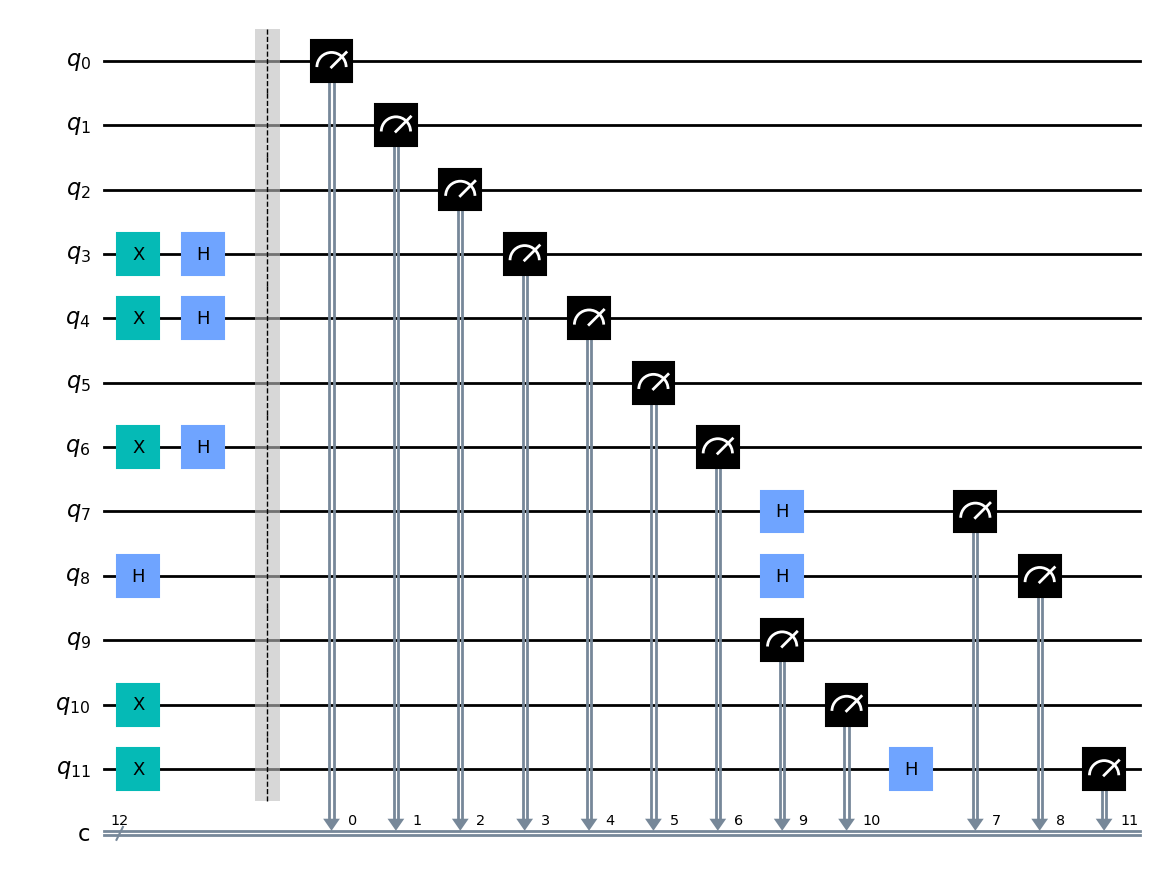

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

def simulate_bb84(num_bits=12):
    """Simulates the BB84 Quantum Key Distribution protocol."""

    # 1. Alice generates random bits and random bases (0 for +, 1 for x)
    alice_bits = np.random.randint(2, size=num_bits)
    alice_bases = np.random.randint(2, size=num_bits)

    # 2. Bob generates random bases for measurement
    bob_bases = np.random.randint(2, size=num_bits)

    # Create a quantum circuit to hold the transmission
    qc = QuantumCircuit(num_bits, num_bits)

    # 3. Alice Encodes her bits into Qubits
    for i in range(num_bits):
        if alice_bits[i] == 1:
            qc.x(i) # Flip to |1>
        if alice_bases[i] == 1:
            qc.h(i) # Change to diagonal basis (|x>)

    qc.barrier()

    # 4. Bob Measures the Qubits
    for i in range(num_bits):
        if bob_bases[i] == 1:
            qc.h(i) # Revert diagonal basis before standard measurement
        qc.measure(i, i)

    # 5. Execute the transmission (run the circuit once)
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1)

    # Qiskit reads right-to-left, so we reverse the output string
    measured_string = list(job.result().get_counts().keys())[0]
    bob_bits = [int(b) for b in measured_string[::-1]]

    # 6. Key Sifting (Comparing Bases)
    secure_key = []
    for i in range(num_bits):
        if alice_bases[i] == bob_bases[i]:
            secure_key.append(str(alice_bits[i]))

    # --- Formatted Output ---
    print("--- BB84 Protocol Execution ---")
    print(f"Alice's Secret Bits : {alice_bits}")
    print(f"Alice's Bases (0=+, 1=x): {alice_bases}")
    print(f"Bob's Guess Bases   : {bob_bases}")
    print(f"Bob's Measured Bits : {bob_bits}")
    print("-" * 31)
    print(f"Final Secure Key: {''.join(secure_key)}")
    print(f"Key Length Retained: {len(secure_key)} out of {num_bits} bits")

    # Draw the transmission circuit
    display(qc.draw('mpl', style='clifford'))

# Run the protocol
simulate_bb84(12)